In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
PROJECT_ROOT = next(
    path for path in _candidates
    if (path / "pyproject.toml").exists() and (path / "src" / "us_gdp_regime").exists()
)
os.chdir(PROJECT_ROOT)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

In [2]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
from IPython.display import HTML, Image, Markdown, display

warnings.filterwarnings("ignore", message="urllib3 .*", category=Warning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

CSS = """
<style>
:root { --ink:#17202A; --muted:#5D6D7E; --line:#DDE3EA; --blue:#2457A6; --green:#168A60; --red:#B23B3B; --gold:#C49A21; --bg:#FBFCFE; }
.nb-hero { border-left: 7px solid var(--blue); padding: 18px 22px; background: linear-gradient(90deg,#F3F7FD,#FFFFFF); margin: 8px 0 18px 0; }
.nb-hero h1 { margin: 0 0 6px 0; font-size: 30px; color: var(--ink); }
.nb-hero p { margin: 0; color: var(--muted); font-size: 15px; }
.nb-callout { border:1px solid var(--line); border-left:5px solid var(--gold); border-radius:8px; background:#fffdf5; padding:14px 16px; margin:12px 0; color:var(--ink); }
.nb-grid { display:grid; grid-template-columns: repeat(auto-fit, minmax(185px, 1fr)); gap:12px; margin: 14px 0 18px 0; }
.nb-card { border:1px solid var(--line); border-radius:8px; background:#fff; padding:14px 16px; }
.nb-card .label { color:var(--muted); font-size:12px; text-transform:uppercase; letter-spacing:.04em; }
.nb-card .value { color:var(--ink); font-size:24px; font-weight:700; margin-top:4px; }
.nb-card .note { color:var(--muted); font-size:12px; margin-top:4px; }
.nb-section { font-size:22px; font-weight:700; color:var(--ink); margin: 24px 0 8px 0; }
.nb-note { color: var(--muted); font-size: 13px; }
</style>
"""
display(HTML(CSS))

def section(title: str) -> None:
    display(HTML(f'<div class="nb-section">{title}</div>'))

def cards(items: list[tuple[str, str, str]]) -> None:
    html = '<div class="nb-grid">'
    for label, value, note in items:
        html += (
            '<div class="nb-card">'
            f'<div class="label">{label}</div>'
            f'<div class="value">{value}</div>'
            f'<div class="note">{note}</div>'
            '</div>'
        )
    html += '</div>'
    display(HTML(html))

def pct(value: float) -> str:
    return f"{value:,.1f}%"

<div class="nb-hero">
<h1>Fiscal Debt and Tax-Regime Context</h1>
<p>Public debt, federal budget ratios, and major tax-law changes are layered onto the GDP regime analysis. The evidence here is descriptive: it tests timing, alignment, and association, not causal tax multipliers.</p>
</div>

In [3]:
from us_gdp_regime.config import load_config
from us_gdp_regime.fiscal import FISCAL_VARIABLE_LABELS
from us_gdp_regime.pipeline import make_fiscal_context

CONFIG_PATH = Path("config/default.yaml")
config = load_config(CONFIG_PATH)
outputs = make_fiscal_context(config)
outputs

{'fiscal_ratios': WindowsPath('data/models/fiscal_ratios.csv'),
 'fiscal_context': WindowsPath('data/models/fiscal_context.csv'),
 'fiscal_growth_correlations': WindowsPath('data/models/fiscal_growth_correlations.csv'),
 'tax_regime_events': WindowsPath('data/models/tax_regime_events.csv'),
 'tax_event_growth_windows': WindowsPath('data/models/tax_event_growth_windows.csv'),
 'fiscal_growth_association': WindowsPath('data/models/fiscal_growth_association.csv'),
 'fiscal_context_figure': WindowsPath('figures/fiscal_context.png'),
 'tax_event_growth_windows_figure': WindowsPath('figures/tax_event_growth_windows.png')}

In [4]:
paths = {
    "series": Path("data/processed/us_gdp_series.csv"),
    "segments": Path("data/models/regime_segments.csv"),
    "fiscal_ratios": Path("data/models/fiscal_ratios.csv"),
    "fiscal_context": Path("data/models/fiscal_context.csv"),
    "correlations": Path("data/models/fiscal_growth_correlations.csv"),
    "association": Path("data/models/fiscal_growth_association.csv"),
    "tax_events": Path("data/models/tax_regime_events.csv"),
    "event_windows": Path("data/models/tax_event_growth_windows.csv"),
    "fiscal_figure": Path("figures/fiscal_context.png"),
    "tax_figure": Path("figures/tax_event_growth_windows.png"),
}

series = pd.read_csv(paths["series"])
segments = pd.read_csv(paths["segments"])
fiscal_ratios = pd.read_csv(paths["fiscal_ratios"])
fiscal_context = pd.read_csv(paths["fiscal_context"])
correlations = pd.read_csv(paths["correlations"])
association = pd.read_csv(paths["association"])
tax_events = pd.read_csv(paths["tax_events"])
event_windows = pd.read_csv(paths["event_windows"])

coverage_start = int(fiscal_context["year"].min())
coverage_end = int(fiscal_context["year"].max())
max_debt = fiscal_context.loc[fiscal_context["gross_debt_gdp"].idxmax()]
mean_receipts = float(fiscal_context["receipts_gdp"].mean())
mean_outlays = float(fiscal_context["outlays_gdp"].mean())

cards([
    ("Fiscal overlap", f"{coverage_start}-{coverage_end}", f"{len(fiscal_context):,} annual GDP/fiscal observations"),
    ("Peak gross debt/GDP", pct(float(max_debt["gross_debt_gdp"])), f"Observed in {int(max_debt['year'])}"),
    ("Mean receipts/GDP", pct(mean_receipts), "Federal receipts over fiscal-overlap panel"),
    ("Mean outlays/GDP", pct(mean_outlays), "Federal outlays over fiscal-overlap panel"),
    ("Tax events", f"{len(tax_events)}", "Broad federal tax-regime shifts catalogued"),
])

<div class="nb-callout"><strong>Identification caveat.</strong> Debt and tax policy are not randomly assigned. They move with wars, recessions, inflation, monetary policy, demographics, and GDP itself. The tables below describe whether fiscal variables and tax-regime changes line up with growth regimes; they do not prove that the policy variable caused the growth outcome.</div>

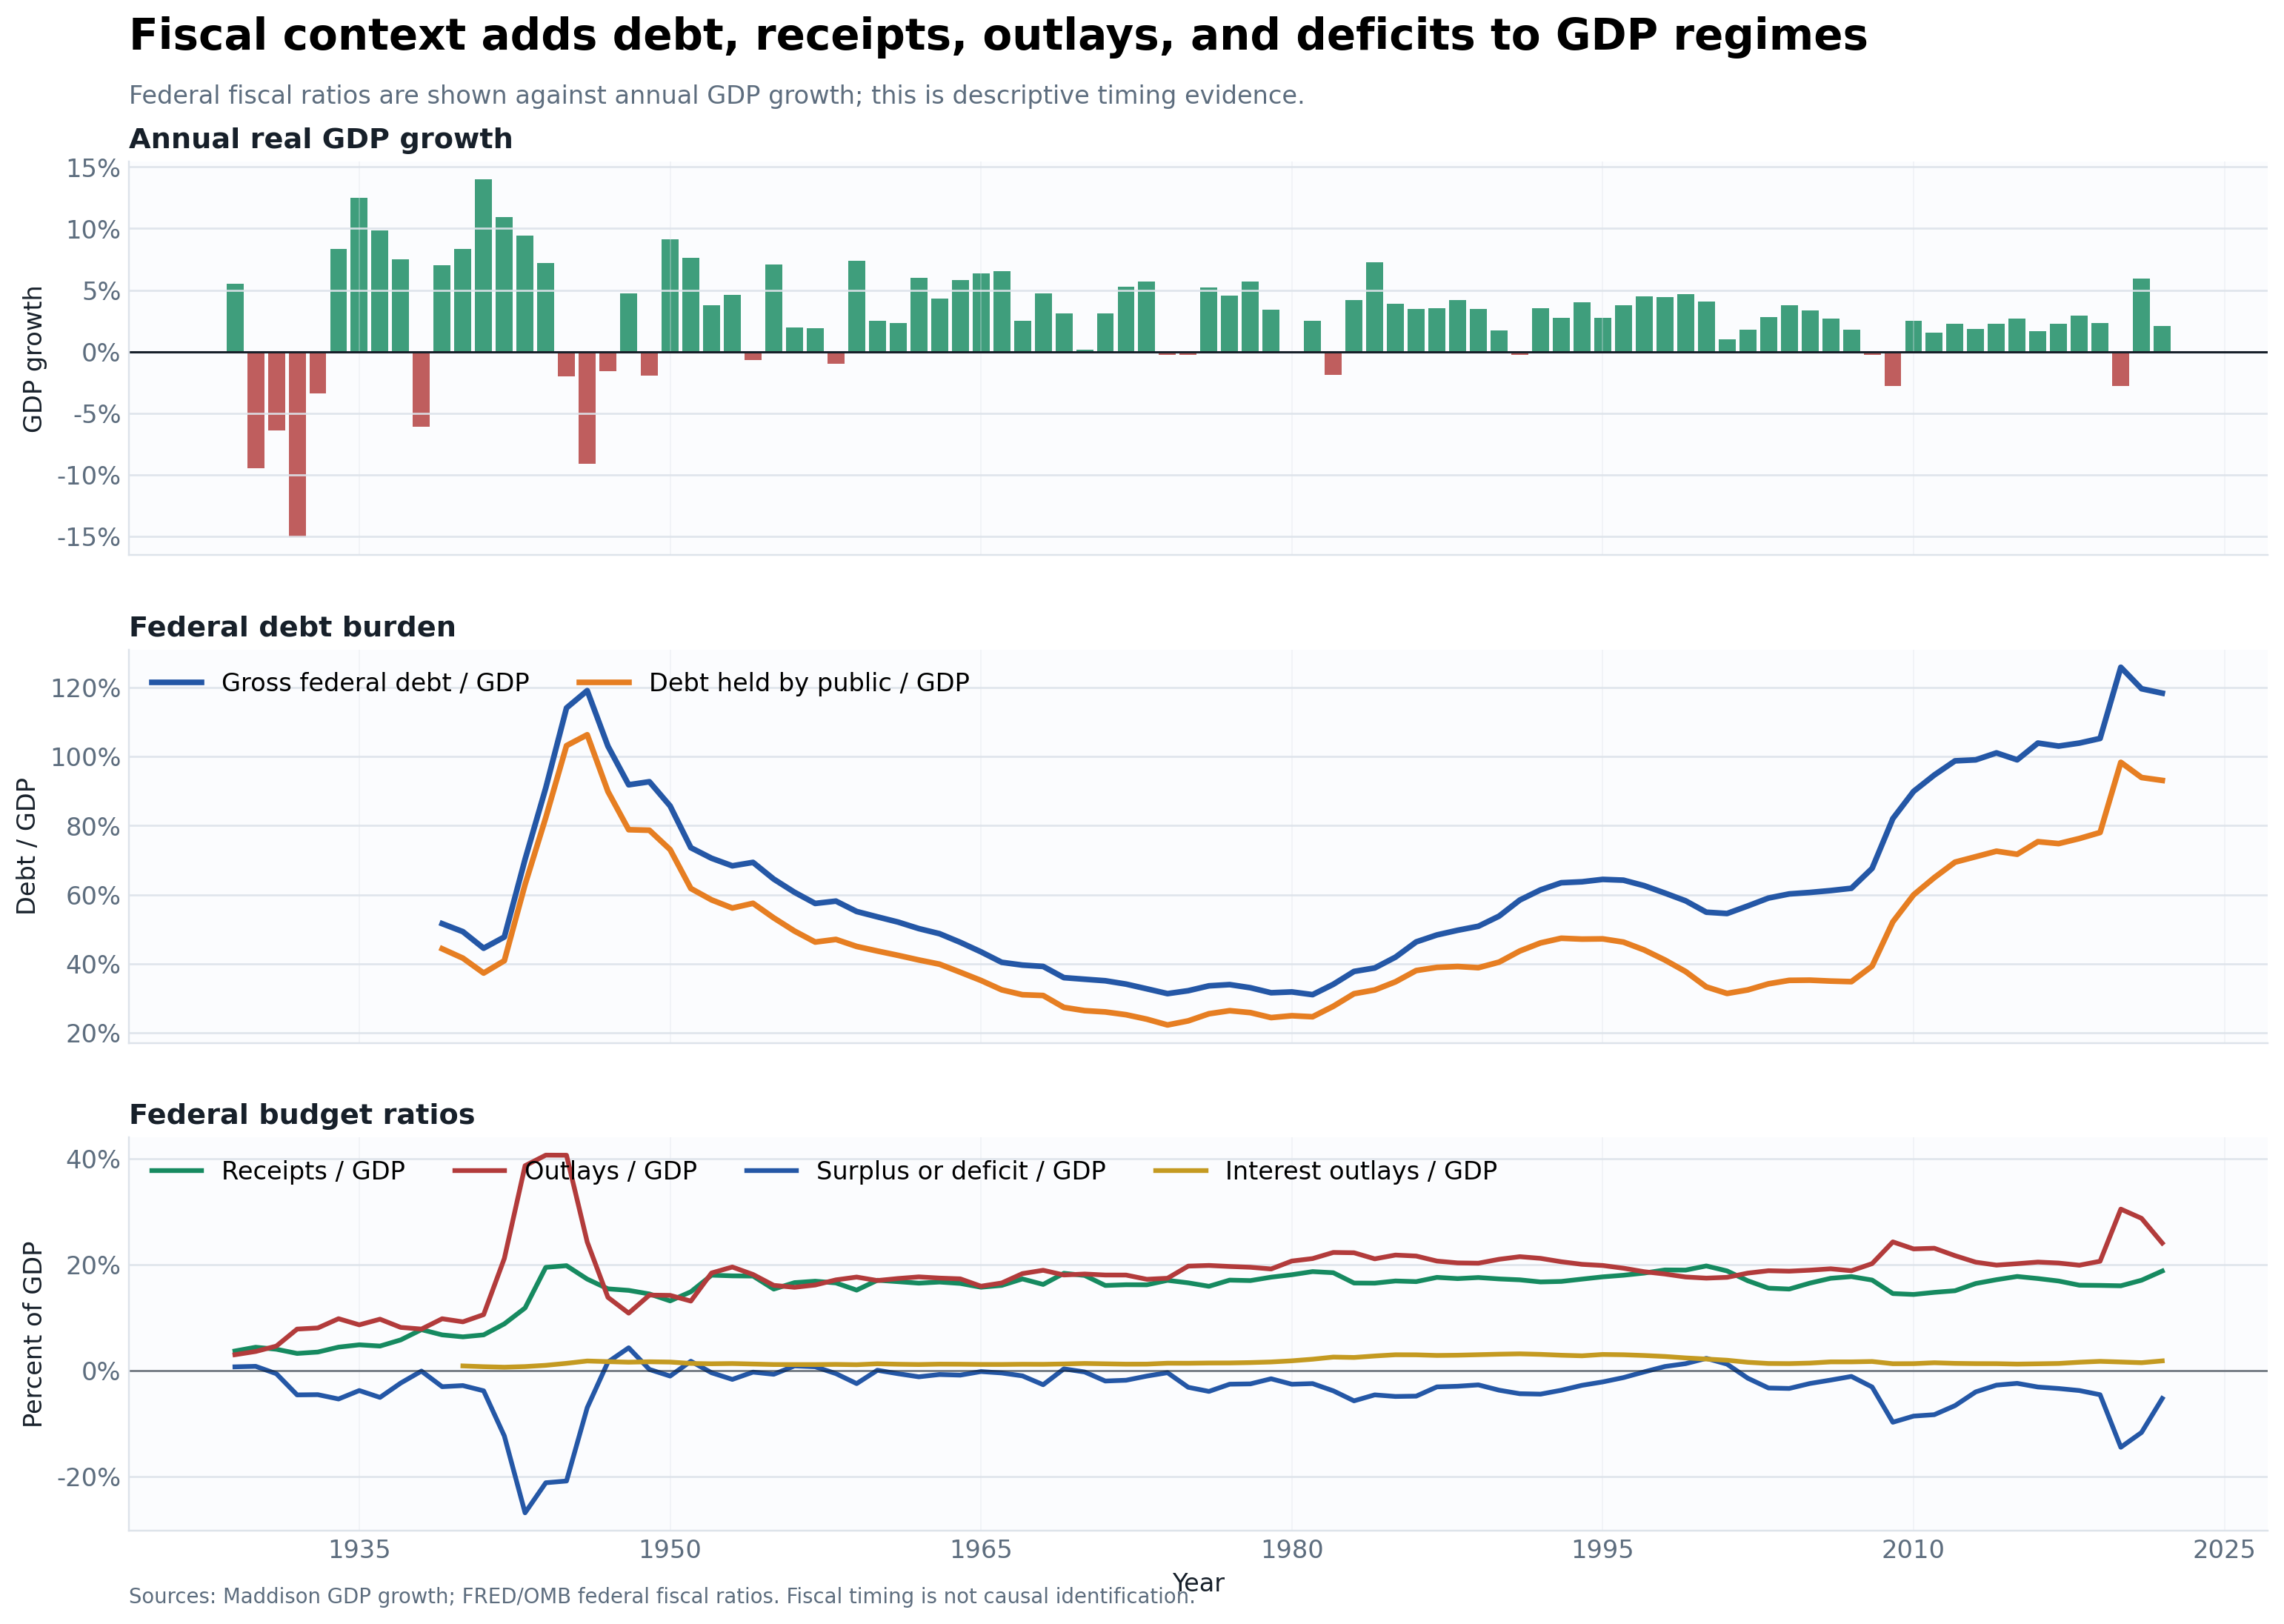

In [5]:
section("Fiscal Ratios and GDP Growth")
display(Image(filename=str(paths["fiscal_figure"])))

In [6]:
section("Fiscal Coverage")
coverage = []
for column, label in FISCAL_VARIABLE_LABELS.items():
    if column in fiscal_ratios.columns:
        non_null = fiscal_ratios.dropna(subset=[column])
        coverage.append({
            "variable": label,
            "first_year": int(non_null["year"].min()),
            "last_year": int(non_null["year"].max()),
            "observations": int(len(non_null)),
        })
display(pd.DataFrame(coverage))

,variable,first_year,last_year,observations
0,Gross federal debt / GDP,1939,2025,87
1,Debt held by public / GDP,1939,2025,87
2,Federal receipts / GDP,1929,2025,97
3,Federal outlays / GDP,1929,2025,97
4,Federal surplus or deficit / GDP,1929,2025,97
5,Federal interest outlays / GDP,1940,2025,86


In [7]:
section("Correlation Screen")
correlation_view = correlations.assign(
    same_year=lambda df: df["correlation_same_year"].map(lambda value: f"{value:+.3f}"),
    lag_1=lambda df: df["correlation_lag1"].map(lambda value: f"{value:+.3f}"),
)[["label", "n_same_year", "same_year", "n_lag1", "lag_1"]]
display(correlation_view)

strongest = correlations.assign(abs_lag=lambda df: df["correlation_lag1"].abs()).sort_values("abs_lag", ascending=False).iloc[0]
display(Markdown(
    f"The largest one-year-lag absolute correlation in this screen is **{strongest['label']}** "
    f"at **{strongest['correlation_lag1']:+.3f}**. Treat this as a triage statistic, not a causal result."
))

,label,n_same_year,same_year,n_lag1,lag_1
0,Gross federal debt / GDP,84,-0.317,83,-0.261
1,Debt held by public / GDP,84,-0.267,83,-0.217
2,Federal receipts / GDP,94,-0.006,93,-0.053
3,Federal outlays / GDP,94,+0.047,93,-0.035
4,Federal surplus or deficit / GDP,94,-0.068,93,-0.002
5,Federal interest outlays / GDP,83,-0.186,82,-0.104


The largest one-year-lag absolute correlation in this screen is **Gross federal debt / GDP** at **-0.261**. Treat this as a triage statistic, not a causal result.

In [8]:
section("Descriptive Fiscal Regression")
association_view = association.copy()
association_view["coefficient"] = association_view["coefficient"].map(lambda value: f"{value:+.3f}")
association_view["std_error"] = association_view["std_error"].map(lambda value: f"{value:.3f}")
association_view["p_value"] = association_view["p_value"].map(lambda value: f"{value:.3f}")
association_view["r_squared"] = association_view["r_squared"].map(lambda value: f"{value:.3f}")
display(association_view[["term", "coefficient", "std_error", "p_value", "n_observations", "r_squared"]])
display(Markdown(
    "The regression uses one-year-lag fiscal ratios and annual GDP growth. "
    "Because fiscal policy reacts to the same macro shocks that affect GDP, the coefficients should be read as conditional associations."
))

,term,coefficient,std_error,p_value,n_observations,r_squared
0,const,+20.214,2.169,0.000,82,0.458
1,gross_debt_gdp_lag1,-0.025,0.012,0.035,82,0.458
2,receipts_gdp_lag1,-0.985,0.136,0.000,82,0.458
3,deficit_gdp_lag1,+0.098,0.060,0.108,82,0.458
4,interest_gdp_lag1,+0.640,0.449,0.158,82,0.458


The regression uses one-year-lag fiscal ratios and annual GDP growth. Because fiscal policy reacts to the same macro shocks that affect GDP, the coefficients should be read as conditional associations.

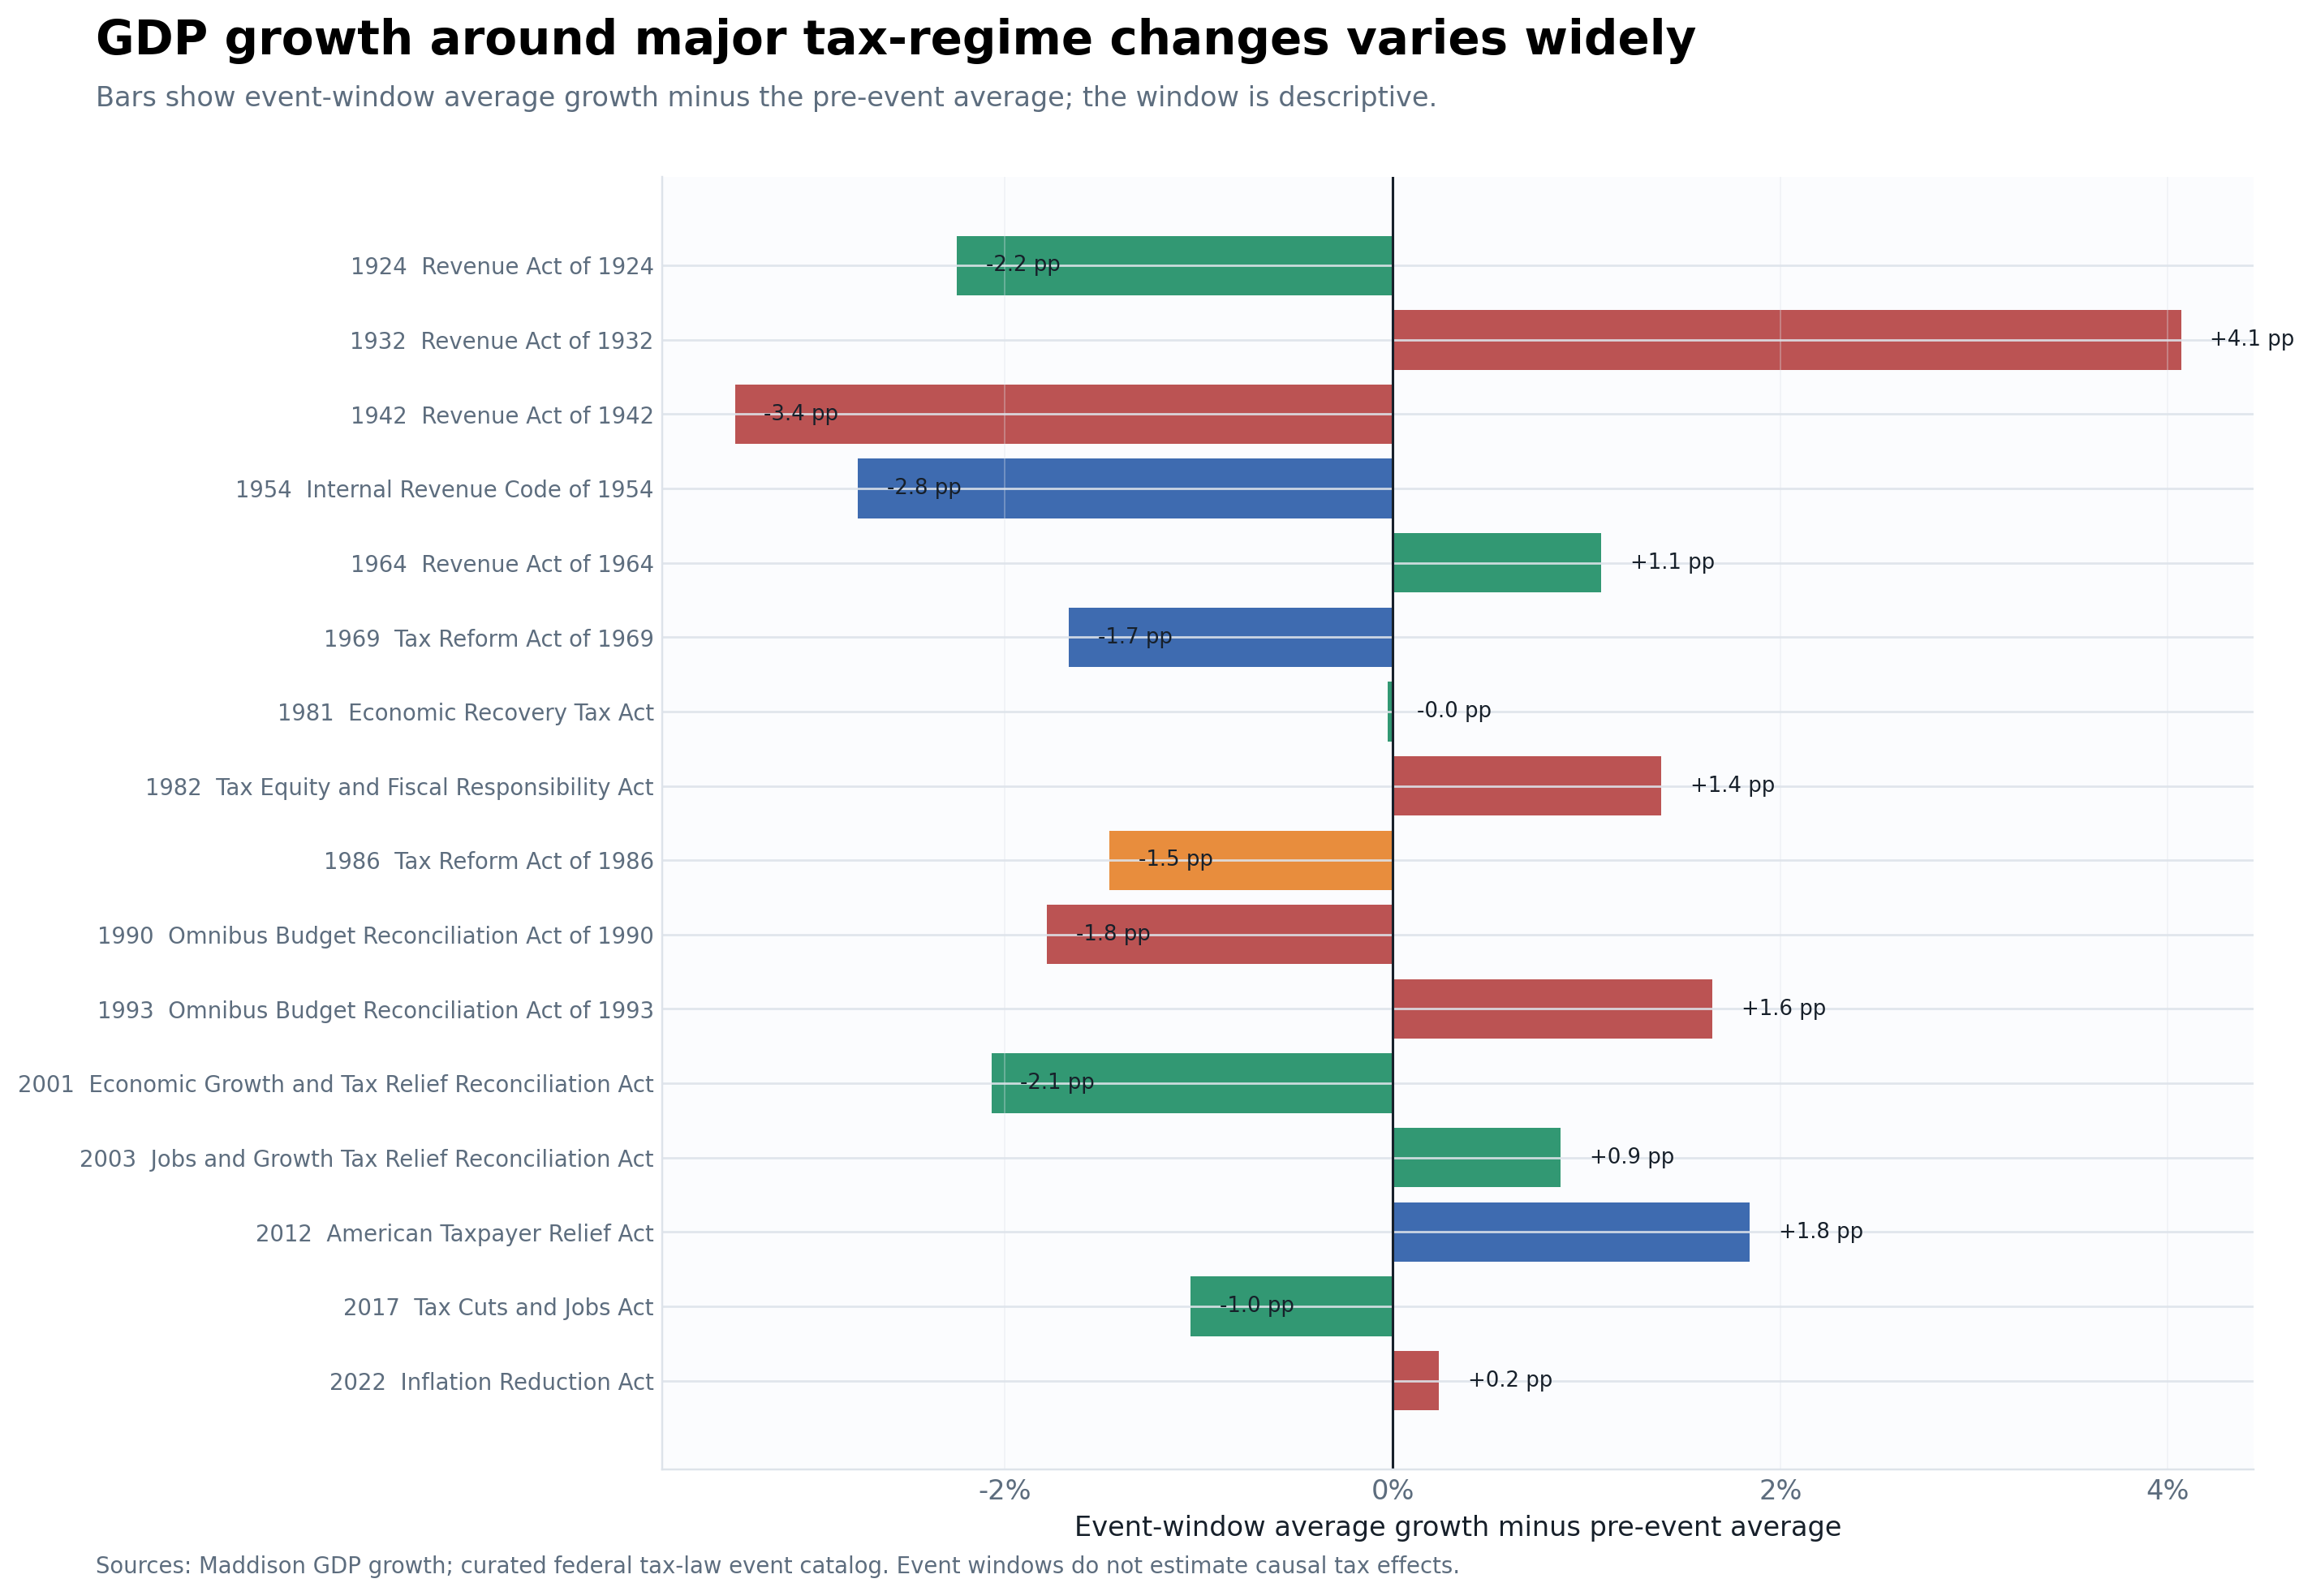

In [9]:
section("Tax-Regime Event Windows")
display(Image(filename=str(paths["tax_figure"])))

In [10]:
event_view = event_windows.copy()
for column in ["pre_mean_growth", "event_window_mean_growth", "event_window_minus_pre"]:
    event_view[column] = event_view[column].map(lambda value: "" if pd.isna(value) else f"{value:+.2f}")

display(event_view[[
    "year",
    "event",
    "direction",
    "n_pre",
    "n_event_window",
    "pre_mean_growth",
    "event_window_mean_growth",
    "event_window_minus_pre",
]])

,year,event,direction,n_pre,n_event_window,pre_mean_growth,event_window_mean_growth,event_window_minus_pre
0,1921,Revenue Act of 1921,decrease,0,4,,+4.25,
1,1924,Revenue Act of 1924,decrease,3,4,+4.85,+2.61,-2.25
2,1932,Revenue Act of 1932,increase,3,4,-3.47,+0.59,+4.07
3,1942,Revenue Act of 1942,increase,3,4,+9.78,+6.39,-3.39
4,1954,Internal Revenue Code of 1954,mixed,3,4,+5.32,+2.56,-2.76
5,1964,Revenue Act of 1964,decrease,3,4,+4.23,+5.31,+1.08
6,1969,Tax Reform Act of 1969,mixed,3,4,+4.60,+2.93,-1.67
7,1981,Economic Recovery Tax Act,decrease,3,4,+3.05,+3.02,-0.02
8,1982,Tax Equity and Fiscal Responsibility Act,increase,3,4,+1.98,+3.37,+1.39
9,1986,Tax Reform Act of 1986,base_broadening,3,4,+5.12,+3.66,-1.46


In [11]:
section("Regime Alignment")
regime_alignment = fiscal_context.groupby("segment_regime", dropna=False).agg(
    years=("year", "count"),
    mean_growth=("gdp_growth", "mean"),
    mean_gross_debt_gdp=("gross_debt_gdp", "mean"),
    mean_public_debt_gdp=("public_debt_gdp", "mean"),
    mean_receipts_gdp=("receipts_gdp", "mean"),
    mean_outlays_gdp=("outlays_gdp", "mean"),
    mean_deficit_gdp=("deficit_gdp", "mean"),
).reset_index()
display(regime_alignment)

display(Markdown(
    "This grouping asks whether above-mean and below-mean GDP segments carried different fiscal backdrops. "
    "It is useful for narrative structure, but still descriptive because the segment labels and fiscal variables are jointly shaped by macroeconomic shocks."
))

,segment_regime,years,mean_growth,mean_gross_debt_gdp,mean_public_debt_gdp,mean_receipts_gdp,mean_outlays_gdp,mean_deficit_gdp
0,above_mean,84,3.762,60.779,45.579,15.717,19.020,-3.302
1,below_mean,10,-3.879,104.139,91.356,10.096,13.094,-2.998


This grouping asks whether above-mean and below-mean GDP segments carried different fiscal backdrops. It is useful for narrative structure, but still descriptive because the segment labels and fiscal variables are jointly shaped by macroeconomic shocks.

### Source Notes

- GDP growth uses the Maddison-derived United States real GDP proxy from the earlier notebooks.
- Fiscal ratios are FRED/OMB annual federal series: gross debt, debt held by the public, receipts, outlays, deficit/surplus, and interest outlays as a percent of GDP.
- Tax-regime events are a curated federal event catalog designed for broad historical context. For a deeper tax-rate dataset, IRS SOI Historical Table 23 can be used to extend this into statutory bracket-rate time series.